Case study 1: Predict the species of an iris flower based on its physical measurements.

In [38]:
from pylab import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
# Combine features and labels into the format your code expects
data = np.column_stack([iris.data, iris.target])

In [39]:
def load_data():
    URL_ = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    data = pd.read_csv(URL_, header=None)
    print(data)

    # make the dataset linearly separable
    data = data[:100]
    data[4] = np.where(data.iloc[:, -1] == 'Iris-setosa', 0, 1)
    data = np.asmatrix(data, dtype='float64')
    return data

Total samples: 150

Classes (target): 2 flower species

$\bullet$ Iris-setosa

$\bullet$ Iris-versicolor


Features (inputs): 4 numerical variables

$\bullet$ Sepal length (cm)

$\bullet$ Sepal width (cm)

$\bullet$ Petal length (cm)

$\bullet$ Petal width (cm)

In [40]:
def perceptron(data, num_iter):
    features = data[:, :-1]
    labels = data[:, -1]
    w = np.zeros(shape=(1, features.shape[1] + 1))
    misclassified_ = []

    for epoch in range(num_iter):
        misclassified = 0
        for x, label in zip(features, labels):
            x = np.insert(x, 0, 1)
            y = np.dot(w, x.transpose())
            target = 1.0 if (y > 0) else 0.0

            delta = (label.item(0) - target)  # ← fix here
            if (delta):
                misclassified += 1
                w += (delta * x)

        misclassified_.append(misclassified)
    return (w, misclassified_)

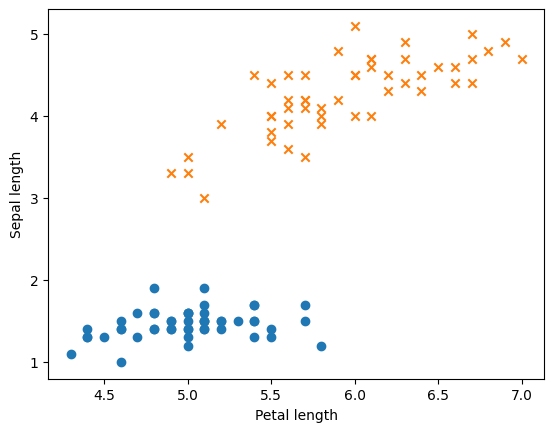

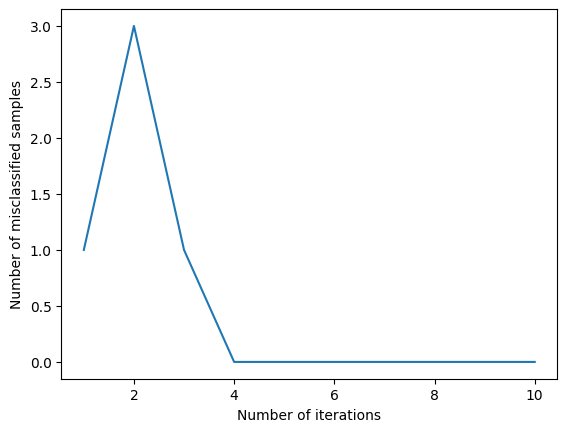

In [41]:
def load_data():
    from sklearn.datasets import load_iris
    import numpy as np
    
    iris = load_iris()
    data = np.column_stack([iris.data, iris.target])
    data = data[:100]
    data[:, -1] = np.where(data[:, -1] == 0, 0, 1)
    
    return data.astype('float64')

if __name__ == "__main__":
    num_iter = 10
    data = load_data()

    mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

    plt.scatter(np.array(data[:50, 0]), np.array(data[:50, 2]), marker='o', label='setosa')
    plt.scatter(np.array(data[50:, 0]), np.array(data[50:, 2]), marker='x', label='versicolor')
    plt.xlabel('Petal length')
    plt.ylabel('Sepal length')
    plt.show()

    w, misclassified_ = perceptron(data, num_iter)
    epochs = np.arange(1, num_iter + 1)

    plt.plot(epochs, misclassified_)
    plt.xlabel('Number of iterations')
    plt.ylabel('Number of misclassified samples')
    plt.show()